In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import time
import os

os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

print("Imports OK")

Imports OK


In [6]:
import requests
from bs4 import BeautifulSoup

# Install beautifulsoup if needed
# import subprocess; subprocess.run(["pip", "install", "beautifulsoup4"])

headers = {
    "User-Agent": "Mozilla/5.0 (Research project, IIT Jodhpur M.Tech thesis)"
}

test_url = "https://shodhganga.inflibnet.ac.in/handle/10603/1/browse?type=title&offset=0"
response = requests.get(test_url, headers=headers, timeout=30)

print(f"Status code: {response.status_code}")
print(f"Page size: {len(response.text)} chars")
print(response.text[:300])

Status code: 200
Page size: 29082 chars


















<!DOCTYPE html>
<html>
    <head>
        <title>Shodhganga@INFLIBNET: Browsing Shodhganga</title>
        <meta http-equiv="Content-Type" content="text/html; charset=UTF-8" />
        <meta name="Generator" content="DSpace 5.3" />
        <meta name="viewport" content="width=devic


In [7]:
import time
import pandas as pd
from bs4 import BeautifulSoup
import requests

headers = {
    "User-Agent": "Mozilla/5.0 (Research project, IIT Jodhpur M.Tech thesis)"
}

def scrape_shodhganga_browse(max_pages=20):
    """
    Scrape thesis metadata from Shodhganga browse pages.
    Each page has ~20 records. 20 pages = ~400 records to start.
    """
    records = []
    offset = 0
    page = 1

    while page <= max_pages:
        url = f"https://shodhganga.inflibnet.ac.in/handle/10603/1/browse?type=title&offset={offset}"
        print(f"Scraping page {page} (offset {offset})...")

        try:
            r = requests.get(url, headers=headers, timeout=30)
            if r.status_code != 200:
                print(f"Got status {r.status_code}, stopping.")
                break

            soup = BeautifulSoup(r.text, "html.parser")

            # Each thesis is in a table row or list item
            items = soup.select("td.oddRowOddCol, td.evenRowOddCol")

            if not items:
                # Try alternate selector
                items = soup.select(".artifact-title a")

            for item in items:
                link = item.find("a")
                if link:
                    records.append({
                        "title": link.get_text(strip=True),
                        "url": "https://shodhganga.inflibnet.ac.in" + link.get("href", ""),
                    })

            print(f"  Found {len(items)} items on this page. Total so far: {len(records)}")
            offset += 20
            page += 1
            time.sleep(2)  # polite delay

        except Exception as e:
            print(f"Error on page {page}: {e}")
            break

    return pd.DataFrame(records)

df_shod = scrape_shodhganga_browse(max_pages=20)
print(f"\nTotal records scraped: {len(df_shod)}")
df_shod.head()

Scraping page 1 (offset 0)...
  Found 40 items on this page. Total so far: 40
Scraping page 2 (offset 20)...
  Found 40 items on this page. Total so far: 80
Scraping page 3 (offset 40)...
  Found 40 items on this page. Total so far: 120
Scraping page 4 (offset 60)...
  Found 40 items on this page. Total so far: 160
Scraping page 5 (offset 80)...
  Found 40 items on this page. Total so far: 200
Scraping page 6 (offset 100)...
  Found 40 items on this page. Total so far: 240
Scraping page 7 (offset 120)...
  Found 40 items on this page. Total so far: 280
Scraping page 8 (offset 140)...
  Found 40 items on this page. Total so far: 320
Scraping page 9 (offset 160)...
  Found 40 items on this page. Total so far: 360
Scraping page 10 (offset 180)...
  Found 40 items on this page. Total so far: 400
Scraping page 11 (offset 200)...
  Found 40 items on this page. Total so far: 440
Scraping page 12 (offset 220)...
  Found 40 items on this page. Total so far: 480
Scraping page 13 (offset 240)...


,title,url
0,35CL NQR studies on some intra And inter molec...,https://shodhganga.inflibnet.ac.in/handle/1060...
1,Jayagopal Uchil,https://shodhganga.inflibnet.ac.in/browse?type...
2,35CL Nuclear quadrupole resonance studies on s...,https://shodhganga.inflibnet.ac.in/handle/1060...
3,Jayagopal Uchil,https://shodhganga.inflibnet.ac.in/browse?type...
4,35CL Nuclear quadrupole resonance study of som...,https://shodhganga.inflibnet.ac.in/handle/1060...


In [8]:
# Scale up once Cell 4 is confirmed working
df_shod = scrape_shodhganga_browse(max_pages=25)
print(f"Total scraped: {len(df_shod)}")
df_shod.to_csv("../data/raw/shodhganga_titles.csv", index=False)
print("Saved to data/raw/shodhganga_titles.csv")

Scraping page 1 (offset 0)...
  Found 40 items on this page. Total so far: 40
Scraping page 2 (offset 20)...
  Found 40 items on this page. Total so far: 80
Scraping page 3 (offset 40)...
  Found 40 items on this page. Total so far: 120
Scraping page 4 (offset 60)...
  Found 40 items on this page. Total so far: 160
Scraping page 5 (offset 80)...
  Found 40 items on this page. Total so far: 200
Scraping page 6 (offset 100)...
  Found 40 items on this page. Total so far: 240
Scraping page 7 (offset 120)...
  Found 40 items on this page. Total so far: 280
Scraping page 8 (offset 140)...
  Found 40 items on this page. Total so far: 320
Scraping page 9 (offset 160)...
  Found 40 items on this page. Total so far: 360
Scraping page 10 (offset 180)...
  Found 40 items on this page. Total so far: 400
Scraping page 11 (offset 200)...
  Found 40 items on this page. Total so far: 440
Scraping page 12 (offset 220)...
  Found 40 items on this page. Total so far: 480
Scraping page 13 (offset 240)...


In [10]:
print(df_shod.columns.tolist())
print(df_shod.head(3))

['title', 'url']
                                               title  \
0  35CL NQR studies on some intra And inter molec...   
1                                    Jayagopal Uchil   
2  35CL Nuclear quadrupole resonance studies on s...   

                                                 url  
0  https://shodhganga.inflibnet.ac.in/handle/1060...  
1  https://shodhganga.inflibnet.ac.in/browse?type...  
2  https://shodhganga.inflibnet.ac.in/handle/1060...  


In [11]:
# First clean the dataframe - keep only actual thesis handle URLs
df_shod_clean = df_shod[df_shod['url'].str.contains("/handle/10603/")].copy()
df_shod_clean = df_shod_clean[~df_shod_clean['url'].str.contains("browse")].copy()
df_shod_clean = df_shod_clean.drop_duplicates(subset='url').reset_index(drop=True)

print(f"Total rows:        {len(df_shod)}")
print(f"Clean thesis rows: {len(df_shod_clean)}")
print(df_shod_clean.head(5))

Total rows:        1000
Clean thesis rows: 500
                                               title  \
0  35CL NQR studies on some intra And inter molec...   
1  35CL Nuclear quadrupole resonance studies on s...   
2  35CL Nuclear quadrupole resonance study of som...   
3  A comparative analysis of performance of self-...   
4  A comparative study of blood of Indian tiger f...   

                                                 url  
0  https://shodhganga.inflibnet.ac.in/handle/1060...  
1  https://shodhganga.inflibnet.ac.in/handle/1060...  
2  https://shodhganga.inflibnet.ac.in/handle/1060...  
3  https://shodhganga.inflibnet.ac.in/handle/1060...  
4  https://shodhganga.inflibnet.ac.in/handle/1060...  


In [12]:
def fetch_thesis_metadata(thesis_url, headers):
    """Visit one thesis page and extract its metadata."""
    try:
        r = requests.get(thesis_url, headers=headers, timeout=20)
        soup = BeautifulSoup(r.text, "html.parser")

        def get_meta(field):
            # Try meta tags first (fastest)
            tag = soup.find("meta", attrs={"name": field})
            if tag:
                return tag.get("content", "").strip()
            return None

        return {
            "title":      get_meta("DC.title"),
            "author":     get_meta("DC.creator"),
            "abstract":   get_meta("DC.description"),
            "date":       get_meta("DC.date"),
            "subject":    get_meta("DC.subject"),
            "publisher":  get_meta("DC.publisher"),
            "language":   get_meta("DC.language"),
            "url":        thesis_url,
        }

    except Exception as e:
        return {"url": thesis_url, "error": str(e)}


# Test on just 3 records first
for _, row in df_shod_clean.head(3).iterrows():
    meta = fetch_thesis_metadata(row["url"], headers)
    print("\n---")
    for k, v in meta.items():
        print(f"{k}: {v}")
    time.sleep(1)


---
title: 35CL NQR studies on some intra And inter molecular complexes and substituted chlorobenzenes
author: Ramananda, D
abstract: Data not available
date: n.d.
subject: Chlorobenzenes
publisher: Mangalore
language: English
url: https://shodhganga.inflibnet.ac.in/handle/10603/132034

---
title: 35CL Nuclear quadrupole resonance studies on some multi-Substituted Anilines Phenols and Aromatic Alcohols
author: K, Roy Sabastian
abstract: Data not available
date: n.d.
subject: Anilines
publisher: Mangalore
language: English
url: https://shodhganga.inflibnet.ac.in/handle/10603/131641

---
title: 35CL Nuclear quadrupole resonance study of some organic compounds and its temperature dependence
author: Jeethendra Kumar, P. K.
abstract: Data not available
date: n.d.
subject: Nuclear
publisher: Mangalore
language: English
url: https://shodhganga.inflibnet.ac.in/handle/10603/131587


In [13]:
from tqdm import tqdm

all_metadata = []
failed = []

for _, row in tqdm(df_shod_clean.iterrows(), total=len(df_shod_clean)):
    meta = fetch_thesis_metadata(row["url"], headers)
    
    if "error" in meta:
        failed.append(row["url"])
    else:
        all_metadata.append(meta)
    
    time.sleep(1.5)  # polite delay — don't skip this

df_meta = pd.DataFrame(all_metadata)

# Save both formats
df_meta.to_parquet("../data/raw/shodhganga_sample.parquet")
df_meta.to_csv("../data/raw/shodhganga_sample.csv", index=False)

print(f"\nSuccessfully fetched: {len(df_meta)} records")
print(f"Failed:               {len(failed)} records")
print(df_meta.head(3))

100%|██████████| 500/500 [23:43<00:00,  2.85s/it]  



Successfully fetched: 497 records
Failed:               3 records
                                               title                   author  \
0  35CL NQR studies on some intra And inter molec...             Ramananda, D   
1  35CL Nuclear quadrupole resonance studies on s...         K, Roy Sabastian   
2  35CL Nuclear quadrupole resonance study of som...  Jeethendra Kumar, P. K.   

             abstract  date         subject  publisher language  \
0  Data not available  n.d.  Chlorobenzenes  Mangalore  English   
1  Data not available  n.d.        Anilines  Mangalore  English   
2  Data not available  n.d.         Nuclear  Mangalore  English   

                                                 url  
0  https://shodhganga.inflibnet.ac.in/handle/1060...  
1  https://shodhganga.inflibnet.ac.in/handle/1060...  
2  https://shodhganga.inflibnet.ac.in/handle/1060...  


In [14]:
import matplotlib.pyplot as plt

print("=== Shodhganga Sample — EDA ===\n")

total = len(df_meta)

# Coverage stats
has_abstract = df_meta['abstract'].notna() & (df_meta['abstract'] != 'Data not available')
has_date     = df_meta['date'].notna() & (df_meta['date'] != 'n.d.')
has_subject  = df_meta['subject'].notna()
has_author   = df_meta['author'].notna()

print(f"Total records:           {total}")
print(f"With real abstract:      {has_abstract.sum()} ({has_abstract.sum()/total*100:.1f}%)")
print(f"With date:               {has_date.sum()} ({has_date.sum()/total*100:.1f}%)")
print(f"With subject:            {has_subject.sum()} ({has_subject.sum()/total*100:.1f}%)")
print(f"With author:             {has_author.sum()} ({has_author.sum()/total*100:.1f}%)")

# This missing abstract % is a KEY FINDING for your report
print(f"\nMissing abstracts: {total - has_abstract.sum()} records")
print("→ These are candidates for LLM-based abstract generation (Phase 2)")

=== Shodhganga Sample — EDA ===

Total records:           497
With real abstract:      245 (49.3%)
With date:               271 (54.5%)
With subject:            496 (99.8%)
With author:             497 (100.0%)

Missing abstracts: 252 records
→ These are candidates for LLM-based abstract generation (Phase 2)


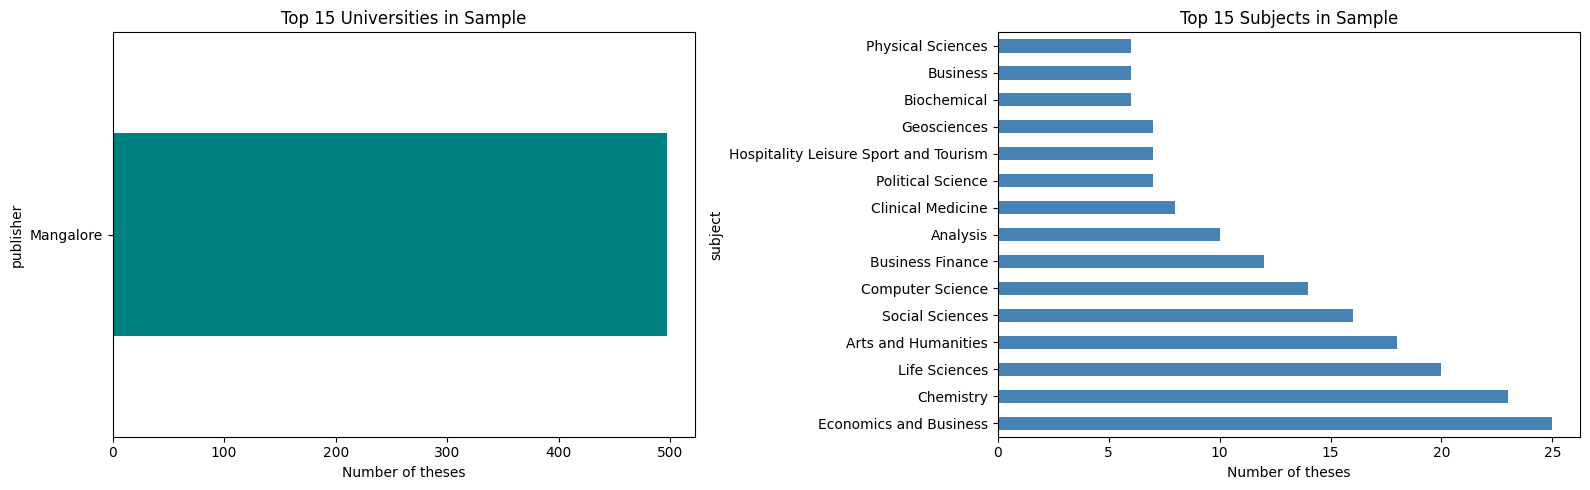

Saved to results/figures/shodhganga_eda.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top universities
df_meta['publisher'].value_counts().head(15).plot(
    kind='barh', ax=axes[0],
    title="Top 15 Universities in Sample",
    color='teal'
)
axes[0].set_xlabel("Number of theses")

# Top subjects
df_meta['subject'].value_counts().head(15).plot(
    kind='barh', ax=axes[1],
    title="Top 15 Subjects in Sample",
    color='steelblue'
)
axes[1].set_xlabel("Number of theses")

plt.tight_layout()
plt.savefig("../results/figures/shodhganga_eda.png", dpi=150)
plt.show()
print("Saved to results/figures/shodhganga_eda.png")

In [16]:
# Load EThOS for comparison
df_ethos = pd.read_parquet("../data/raw/ethos.parquet")

ethos_abstract_col = 'Abstract'
ethos_has_abstract = df_ethos[ethos_abstract_col].notna() & \
                     (df_ethos[ethos_abstract_col].str.strip() != '')

summary = {
    "Repository":        ["EThOS (UK)",           "Shodhganga (India)"],
    "Records":           [len(df_ethos),           len(df_meta)],
    "With Abstract (%)": [
        round(ethos_has_abstract.sum() / len(df_ethos) * 100, 1),
        round(has_abstract.sum() / total * 100, 1)
    ],
    "With Subject (%)":  [
        round(df_ethos['Subject Discipline'].notna().sum() / len(df_ethos) * 100, 1),
        round(has_subject.sum() / total * 100, 1)
    ],
}

comparison_df = pd.DataFrame(summary)
print("\n=== EThOS vs Shodhganga — Metadata Quality Comparison ===")
print(comparison_df.to_string(index=False))

comparison_df.to_csv("../results/scores/metadata_comparison.csv", index=False)
print("\nSaved to results/scores/metadata_comparison.csv")


=== EThOS vs Shodhganga — Metadata Quality Comparison ===
        Repository  Records  With Abstract (%)  With Subject (%)
        EThOS (UK)   639252               61.0             100.0
Shodhganga (India)      497               49.3              99.8

Saved to results/scores/metadata_comparison.csv
